In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data=pd.read_csv('telco_data.csv')

EDA & Cleaning

In [3]:
print(data.shape)

(7043, 21)


In [4]:
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No     1.0           No   
1  5575-GNVDE    Male              0      No         No    34.0          Yes   
2  3668-QPYBK    Male              0      No         No     2.0          Yes   
3  7795-CFOCW    Male              0      No         No    45.0           No   
4  9237-HQITU  Female              0      No         No     2.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data=data.drop(columns=['customerID'],axis=1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5543 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
# gender & pratner & internetService & Streaming TV ---> cat with nulls
# tenure & MonthlyCharge ---> numeric with nulls

categorical feats

In [10]:
print(data['gender'].unique())
print(data['Partner'].unique())
print(data['Dependents'].unique())
print(data['PhoneService'].unique())
print(data['MultipleLines'].unique())
print(data['InternetService'].unique())
print(data['OnlineSecurity'].unique())
print(data['OnlineBackup'].unique())
print(data['DeviceProtection'].unique())
print(data['TechSupport'].unique())
print(data['StreamingTV'].unique())
print(data['StreamingMovies'].unique())
print(data['Contract'].unique())
print(data['PaperlessBilling'].unique())
print(data['PaymentMethod'].unique())
print(data['Churn'].unique())

['Female' 'Male' nan]
['Yes' 'No' nan]
['No' 'Yes']
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No' nan]
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' nan 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['No' 'Yes']


In [11]:
data.loc[(data['StreamingTV']== 'No internet service'), 'InternetService'].isnull().sum()

np.int64(0)

In [12]:
data.loc[(data['InternetService']== 'No'), ['OnlineSecurity', 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']]="No"

In [13]:
print(data['StreamingTV'].unique())
print(data['OnlineSecurity'].unique())
print(data['OnlineBackup'].unique())
print(data['DeviceProtection'].unique())
print(data['TechSupport'].unique())
print(data['StreamingMovies'].unique())

['No' 'Yes' nan]
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


In [14]:
print(data.loc[data['OnlineSecurity']== 'No internet service','InternetService'].unique())
print(data.loc[data['OnlineSecurity']== 'No internet service','InternetService'].isnull().sum())

[nan]
225


In [15]:
data.loc[(data['OnlineSecurity']== 'No internet service'), 'InternetService']="No"

In [16]:
data.loc[(data['InternetService']== 'No'), ['OnlineSecurity', 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','OnlineBackup']]="No"

In [17]:
print(data['StreamingTV'].unique())
print(data['OnlineSecurity'].unique())
print(data['OnlineBackup'].unique())
print(data['DeviceProtection'].unique())
print(data['TechSupport'].unique())
print(data['StreamingMovies'].unique())

['No' 'Yes' nan]
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


In [18]:
data['InternetService'].isnull().sum()

np.int64(775)

In [19]:
print(data.loc[data['InternetService']=='No','StreamingTV'].unique())

['No']


In [20]:
data['StreamingTV'].isnull().sum()

np.int64(1172)

In [21]:
data.loc[data['MultipleLines']=='No phone service','MultipleLines']="No"

In [22]:
print(data['MultipleLines'].unique())

['No' 'Yes']


In [23]:
data.loc[
    pd.to_numeric(data["TotalCharges"], errors="coerce").isna(),
    "TotalCharges"
]


488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object

In [24]:
data.loc[pd.to_numeric(data["TotalCharges"], errors="coerce").isna(),"tenure"]

488     0.0
753     0.0
936     0.0
1082    0.0
1340    NaN
3331    0.0
3826    0.0
4380    0.0
5218    0.0
6670    NaN
6754    NaN
Name: tenure, dtype: float64

In [25]:
data.loc[pd.to_numeric(data["TotalCharges"], errors="coerce").isna(),"TotalCharges"]=0

In [26]:
data.loc[data['TotalCharges']==0,'tenure']=0

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4546 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6268 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5871 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [28]:
data['TotalCharges']=data['TotalCharges'].astype('float64')

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4546 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6268 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5871 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [30]:
data.loc[(data['MonthlyCharges'].notna())&(data['tenure'].isna()),'tenure'].shape[0]

999

In [31]:
data['tenure'].isna().sum()

np.int64(2497)

In [32]:
data.loc[data['tenure'].isna(),
         ['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
8,NaN,NaN,3046.05
12,NaN,100.35,5681.10
14,NaN,NaN,2686.05
15,NaN,NaN,7895.15
17,NaN,NaN,7382.25
...,...,...,...
7031,NaN,60.00,3316.10
7034,NaN,NaN,6886.25
7036,NaN,NaN,743.30
7037,NaN,NaN,1419.40


In [33]:
data.loc[
    ((data['MonthlyCharges'].notna()) & (data['tenure'].isna())),
    'tenure'
] = (
    data.loc[
        ((data['MonthlyCharges'].notna()) & (data['tenure'].isna())),
        'TotalCharges'
    ]
    //
    data.loc[
        ((data['MonthlyCharges'].notna()) & (data['tenure'].isna())),
        'MonthlyCharges'
    ]
).clip(lower=1)

In [34]:
data.loc[
    ((data['MonthlyCharges'].isna()) & (data['tenure'].notna())& (data['tenure']!=0)),
    'MonthlyCharges'
] = (
    data.loc[
        ((data['MonthlyCharges'].isna()) & (data['tenure'].notna())& (data['tenure']!=0)),
        'TotalCharges'
    ]
    /
    data.loc[
        ((data['MonthlyCharges'].isna()) & (data['tenure'].notna())& (data['tenure']!=0)),
        'tenure'
    ]
)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            5545 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6268 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5871 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [36]:
# gender & pratner & internetService & Streaming TV ---> cat with nulls
# tenure & MonthlyCharge ---> numeric with nulls

In [37]:
# dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies ---> cat with no nulls

Univariate analysis

<Axes: ylabel='TotalCharges'>

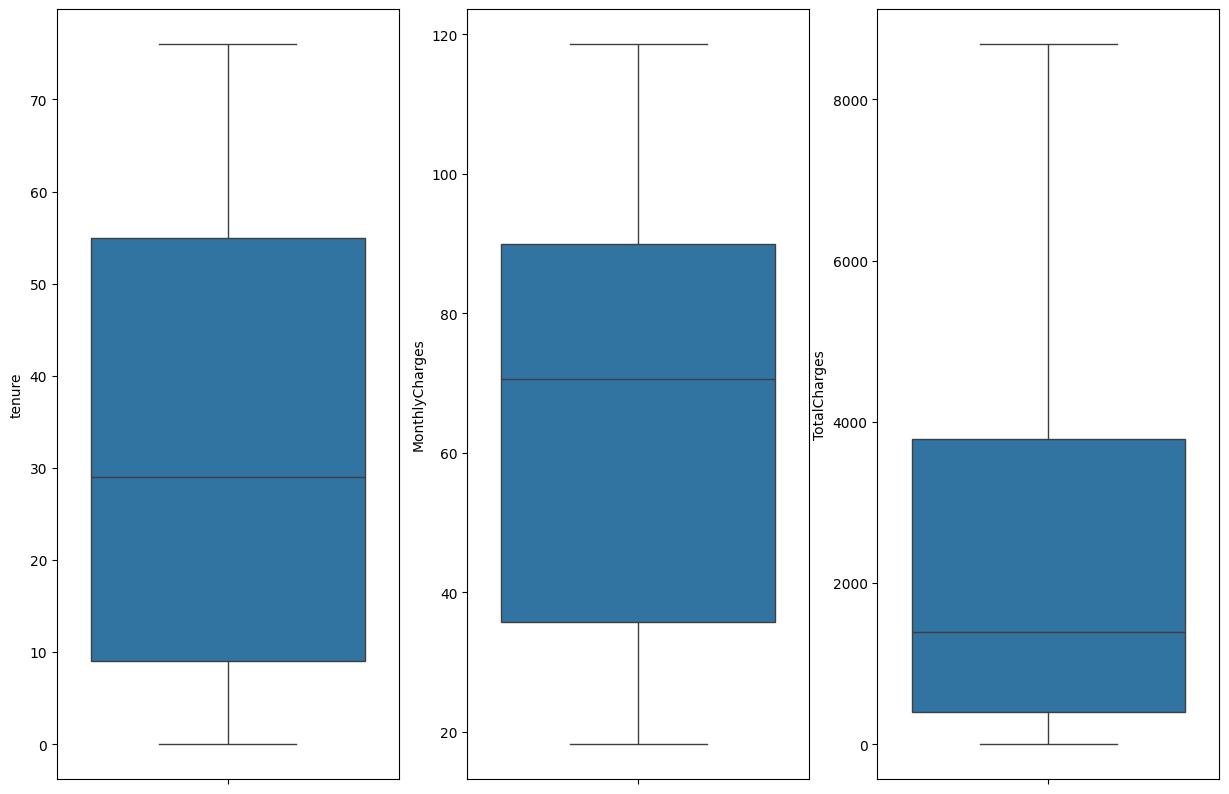

In [38]:
fig,axes=plt.subplots(1,3,figsize=(15,10))
sns.boxplot(data=data,y='tenure',ax=axes[0])
sns.boxplot(data=data,y='MonthlyCharges',ax=axes[1])
sns.boxplot(data=data,y='TotalCharges',ax=axes[2])

<Axes: xlabel='TotalCharges', ylabel='Count'>

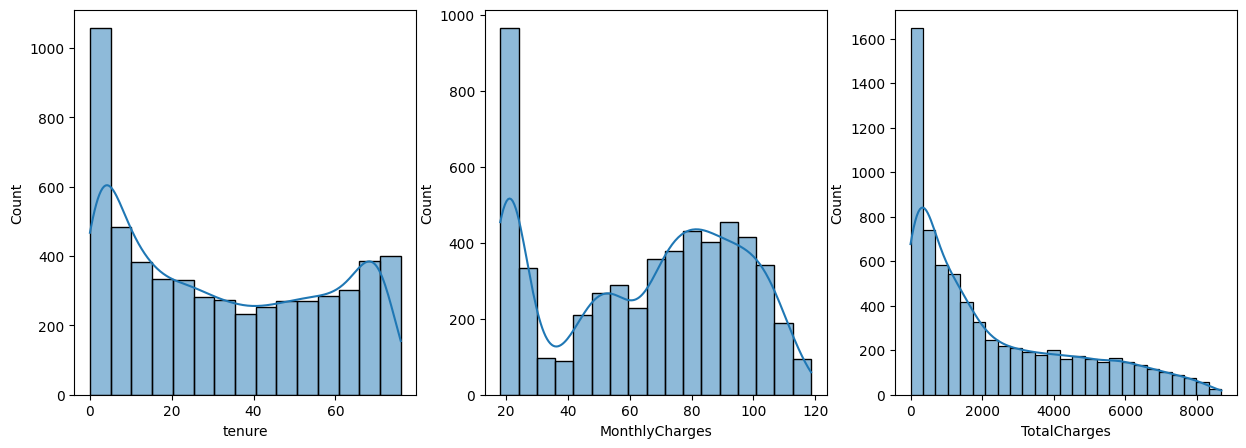

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(data=data, x="tenure", kde=True, ax=axes[0])
sns.histplot(data=data, x="MonthlyCharges", kde=True, ax=axes[1])
sns.histplot(data=data, x="TotalCharges", kde=True, ax=axes[2])

Bivariate analysis

<Axes: xlabel='TotalCharges', ylabel='Count'>

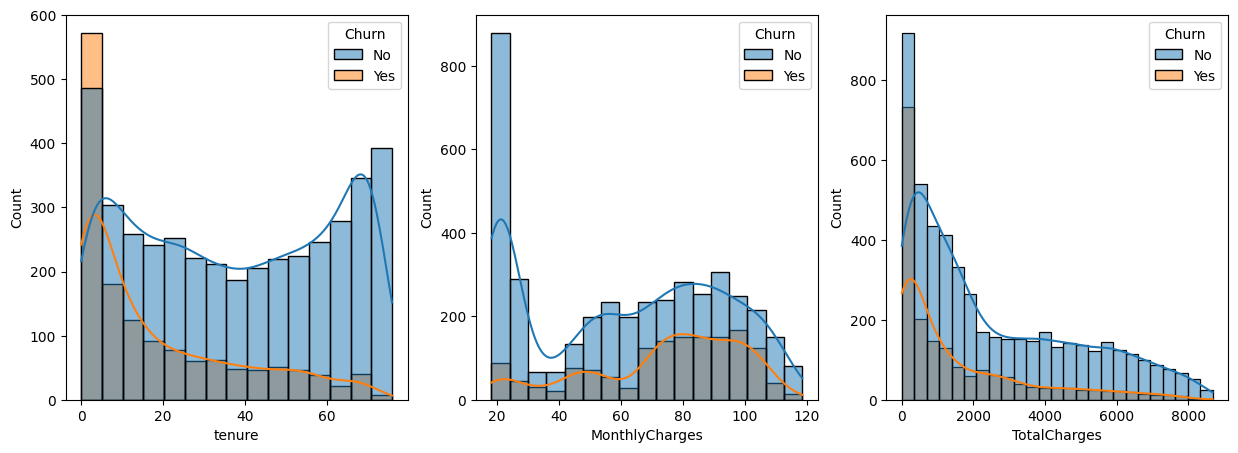

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(data=data, x="tenure", hue="Churn", kde=True, ax=axes[0])
sns.histplot(data=data, x="MonthlyCharges", hue="Churn", kde=True, ax=axes[1])
sns.histplot(data=data, x="TotalCharges", hue="Churn", kde=True, ax=axes[2])

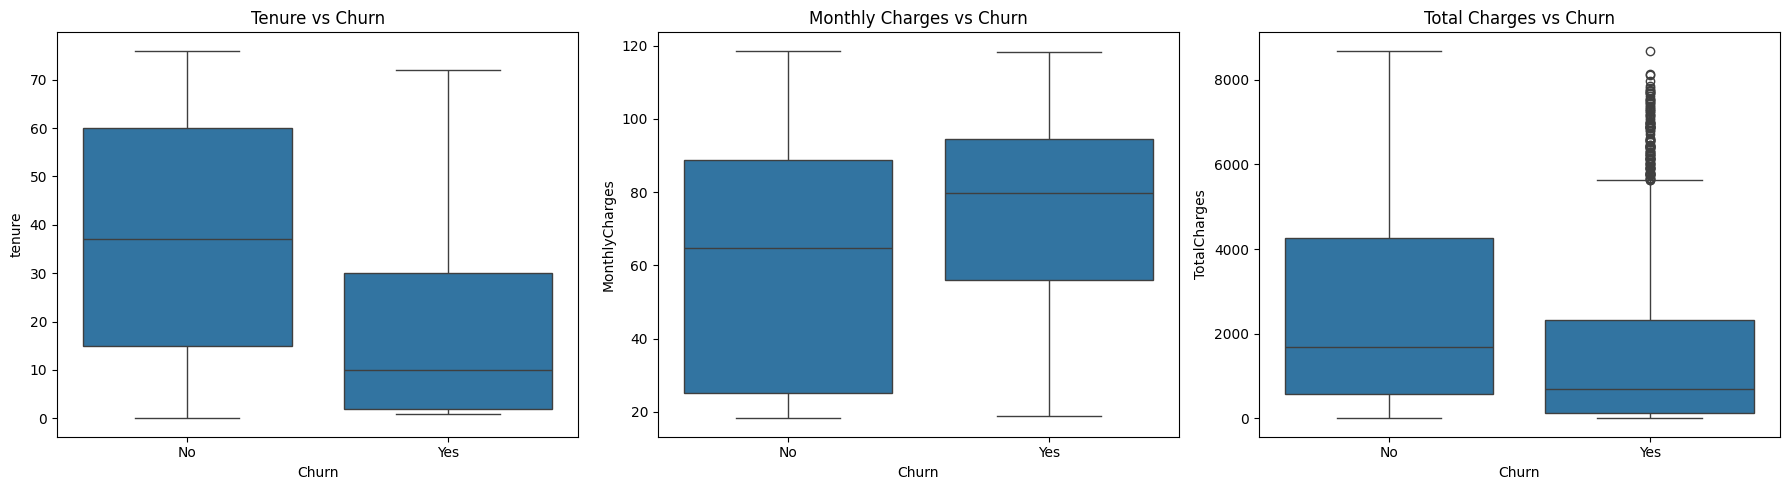

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=data, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=data, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(data=data, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

#Customers with shorter tenure tend to churn more frequently.
customers with higher monthly charges tend to churn more frequently.

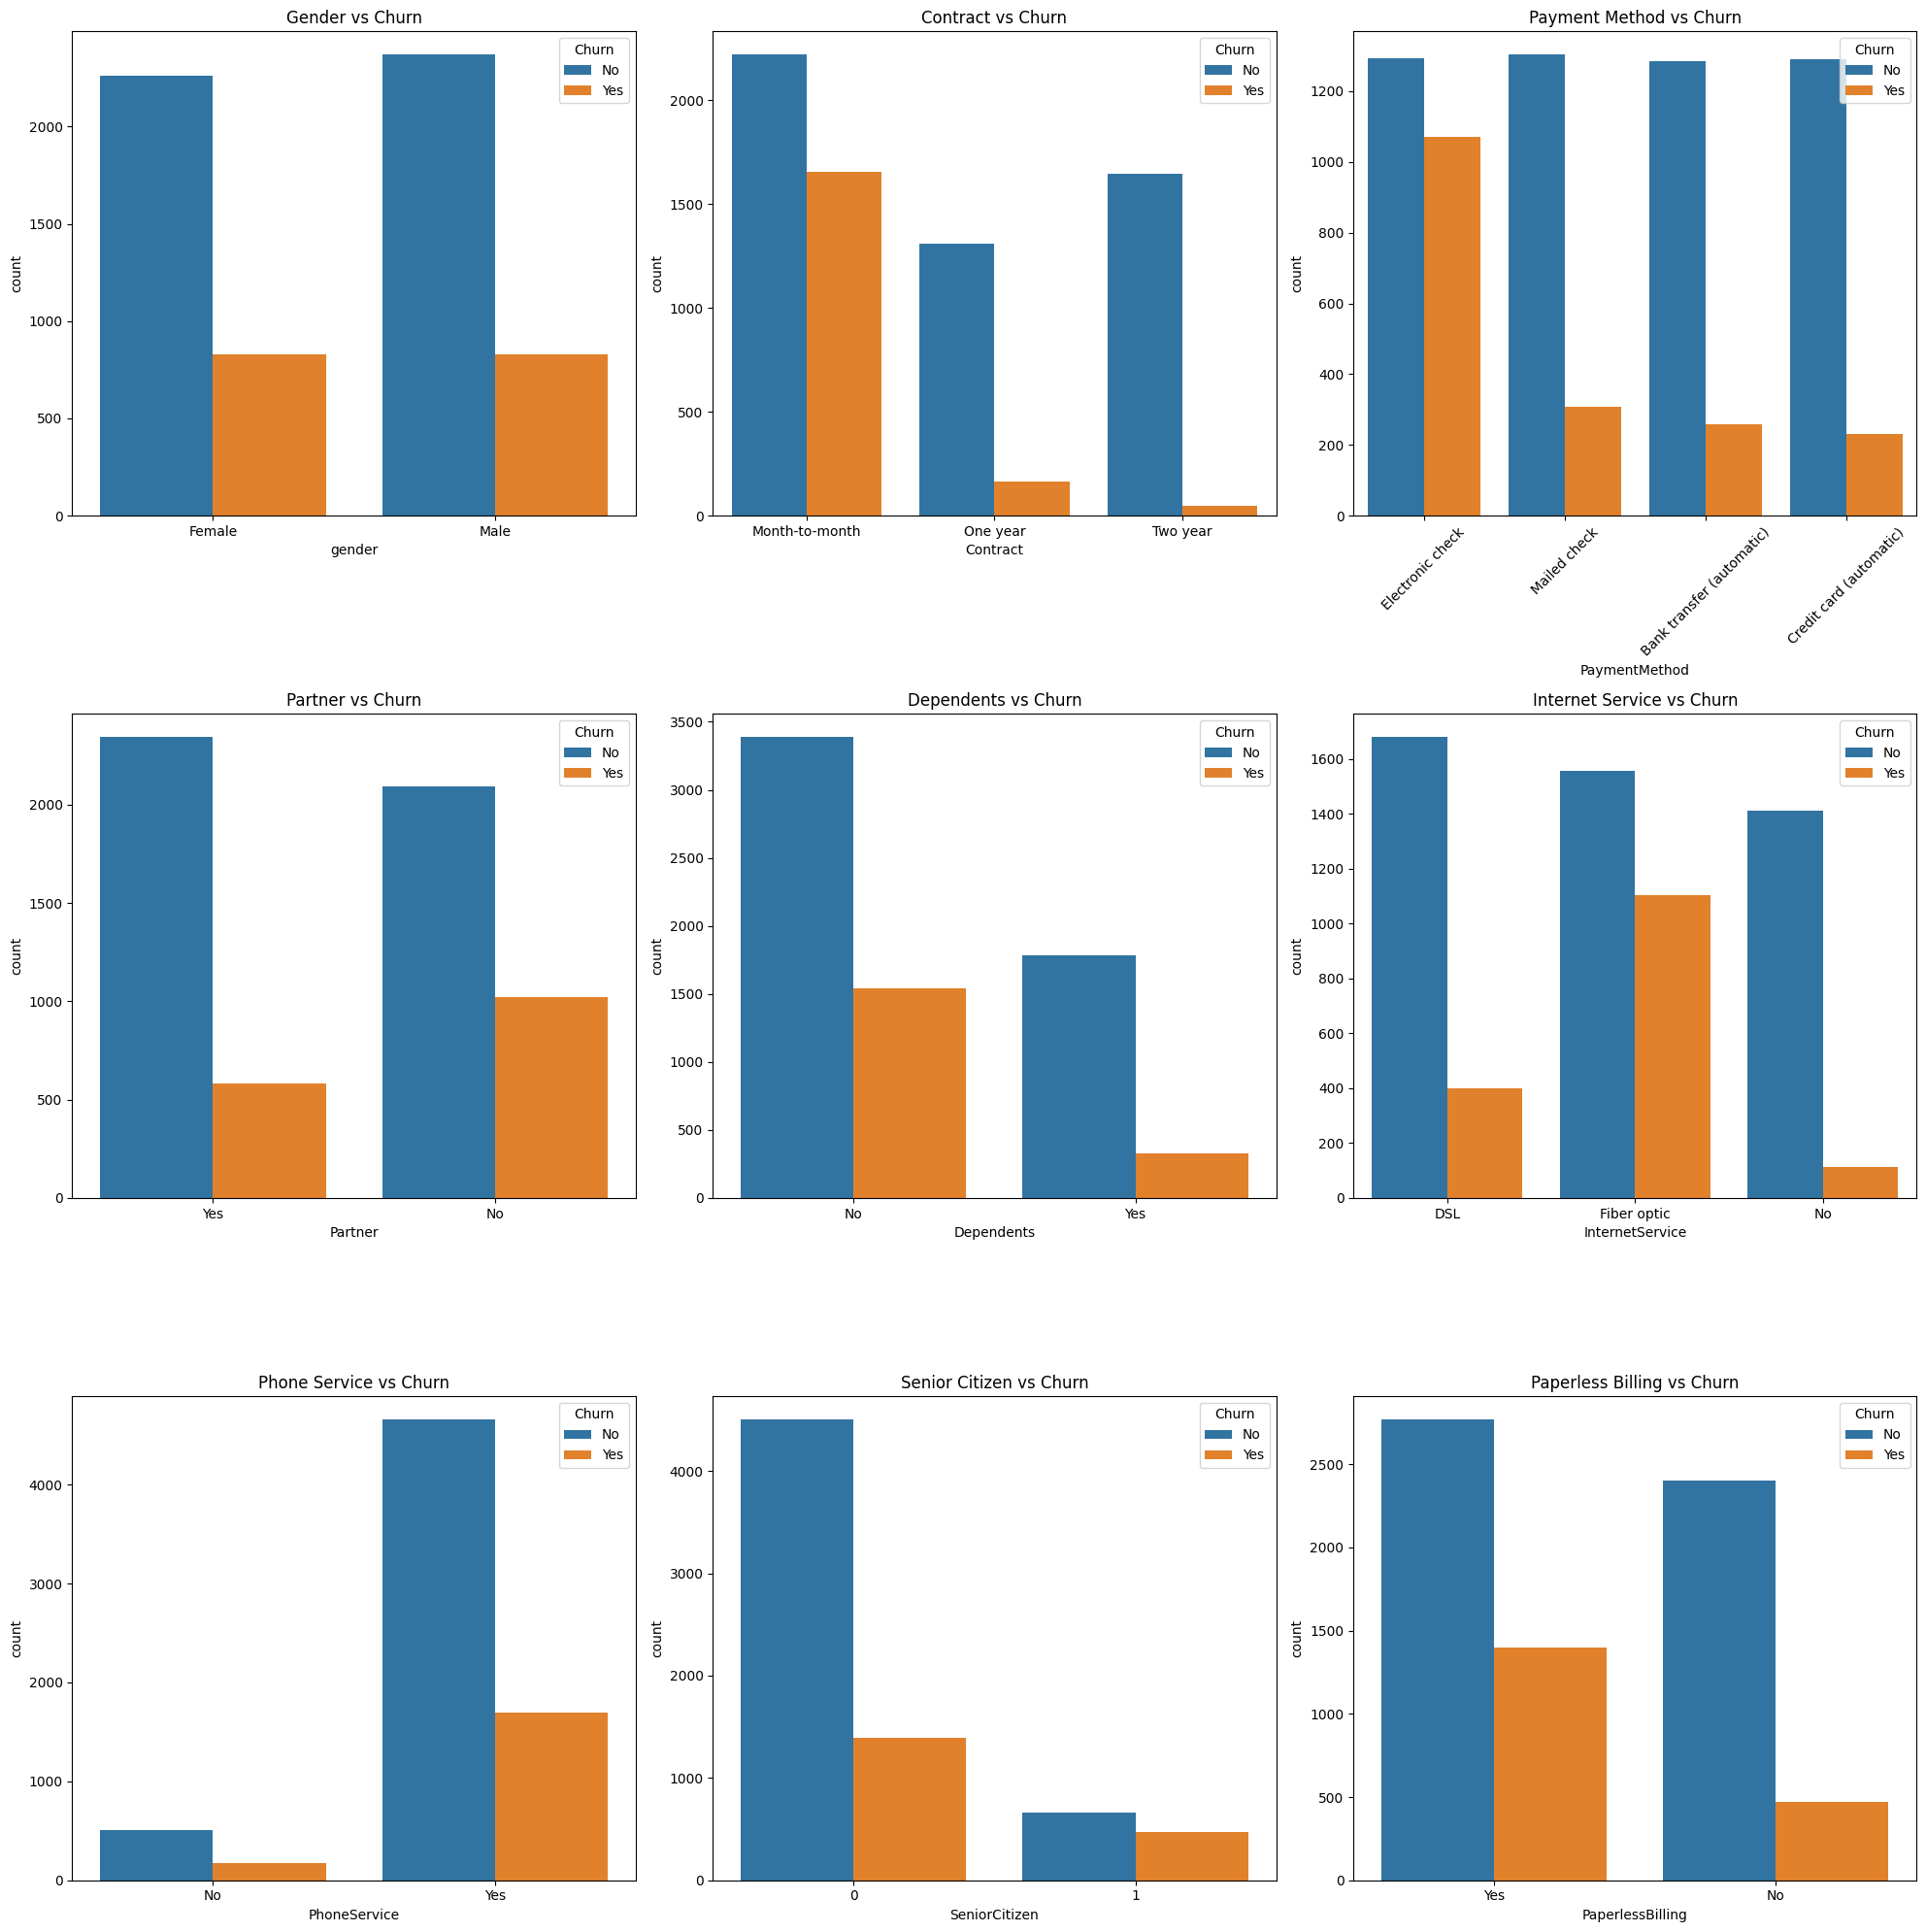

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(20, 20))

sns.countplot(data=data, x="gender", hue="Churn", ax=axes[0][0])
axes[0][0].set_title("Gender vs Churn")

sns.countplot(data=data, x="Contract", hue="Churn", ax=axes[0][1])
axes[0][1].set_title("Contract vs Churn")

sns.countplot(data=data, x="PaymentMethod", hue="Churn", ax=axes[0][2])
axes[0][2].set_title("Payment Method vs Churn")
axes[0][2].tick_params(axis="x", rotation=45)

sns.countplot(data=data, x="Partner", hue="Churn", ax=axes[1][0])
axes[1][0].set_title("Partner vs Churn")

sns.countplot(data=data, x="Dependents", hue="Churn", ax=axes[1][1])
axes[1][1].set_title("Dependents vs Churn")

sns.countplot(data=data, x="InternetService", hue="Churn", ax=axes[1][2])
axes[1][2].set_title("Internet Service vs Churn")

sns.countplot(data=data, x="PhoneService", hue="Churn", ax=axes[2][0])
axes[2][0].set_title("Phone Service vs Churn")

sns.countplot(data=data, x="SeniorCitizen", hue="Churn", ax=axes[2][1])
axes[2][1].set_title("Senior Citizen vs Churn")

sns.countplot(data=data, x="PaperlessBilling", hue="Churn", ax=axes[2][2])
axes[2][2].set_title("Paperless Billing vs Churn")


plt.tight_layout()
plt.show()

In [43]:
# Gender showed limited impact on churn in the EDA.
# It was removed to simplify the feature set.
data=data.drop(columns=['gender'],axis=1)

Target analysis

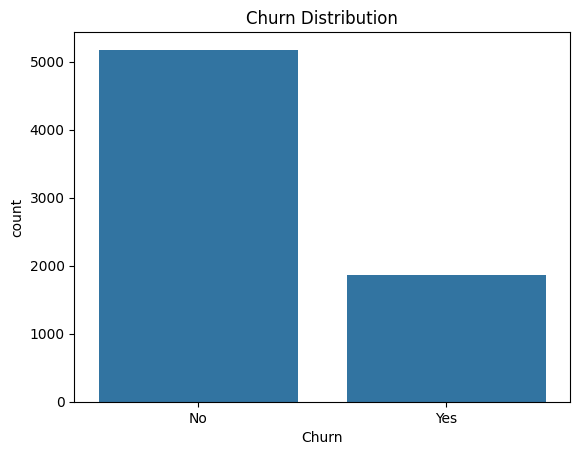

In [44]:
sns.countplot(data=data, x='Churn')
plt.title('Churn Distribution')
plt.show()

#Class imbalance can lead to biased model performance.
Therefore, recall is prioritized because it is more important to identify
customers who are likely to churn than to miss actual churners (false negatives).

In [45]:
print(data.duplicated().sum())

25


In [46]:
data=data.drop_duplicates()
print(data.duplicated().sum())

0


In [47]:
data.isna().sum()

SeniorCitizen          0
Partner             1000
Dependents             0
tenure              1498
PhoneService           0
MultipleLines          0
InternetService      775
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1172
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

*TRAIN TEST SPLIT*

In [48]:
X=data.drop(columns=['Churn'],axis=1)
y=data['Churn']

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True, stratify = y)

In [51]:
churn_mapping = {"Yes": 1, "No": 0}

y_train = y_train.map(churn_mapping)
y_test = y_test.map(churn_mapping)

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV

In [53]:
#Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling ---> binary
#internetService & Contract & PaymentMethod ---> categorical
#tenure & MonthlyCharge & Total Charges ---> numeric

Column Transformer

In [54]:
binary_feat = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

cat_feat = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

num_feat = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [55]:
numeric_transformer = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])
binary_transformer = Pipeline([
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OrdinalEncoder(categories=[["No", "Yes"]] * len(binary_feat)))
])
categorical_transformer = Pipeline([
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
('num', numeric_transformer, num_feat),
('cat', categorical_transformer, cat_feat),
('bin', binary_transformer, binary_feat)
],remainder='passthrough')


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Pipelines & Gridsearch CV

Recall is prioritized because identifying customers who are likely to churn
is important, and missing a churned customer (false negative) may be costly.

In [57]:
#Logistic Regression
logistic_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_params = {
    "feature_selection__k": [5, 10, 15, 20, "all"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear"]
}

logistic_grid = GridSearchCV(
    logistic_pipe,
    param_grid=logistic_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Parameters:", logistic_grid.best_params_)
print("Best CV Recall:", logistic_grid.best_score_)

Best Parameters: {'feature_selection__k': 5, 'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best CV Recall: 0.8418374977437404


In [58]:
SVC_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", SVC())
])

SVC_params = {
    "feature_selection__k": [5, 10, 15, 20, "all"],
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__class_weight": [None, "balanced"]
}
SVC_grid = GridSearchCV(
    SVC_pipe,
    param_grid=SVC_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

SVC_grid.fit(X_train, y_train)

print("Best Parameters:", SVC_grid.best_params_)
print("Best CV Recall:", SVC_grid.best_score_)

Best Parameters: {'feature_selection__k': 5, 'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}
Best CV Recall: 0.882102060287254


In [59]:
RF_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(random_state=42))
])

RF_params = {
    "feature_selection__k": [5, 10, 15, 20, "all"],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

RF_grid = GridSearchCV(
    RF_pipe,
    param_grid=RF_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

RF_grid.fit(X_train, y_train)

print("Best Parameters:", RF_grid.best_params_)
print("Best CV Recall:", RF_grid.best_score_)

Best Parameters: {'feature_selection__k': 5, 'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV Recall: 0.749815631365875


In [60]:
KNN_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", KNeighborsClassifier())
])

KNN_params = {
    "feature_selection__k": [5, 10, 15, 20, "all"],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

KNN_grid = GridSearchCV(
    KNN_pipe,
    param_grid=KNN_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

KNN_grid.fit(X_train, y_train)

print("Best Parameters:", KNN_grid.best_params_)
print("Best CV Recall:", KNN_grid.best_score_)

Best Parameters: {'feature_selection__k': 'all', 'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'uniform'}
Best CV Recall: 0.5168897140352234


In [61]:
GB_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", GradientBoostingClassifier(random_state=42))
])

GB_params = {
    "feature_selection__k": [5, 10, 15, 20, "all"],
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

GB_grid = GridSearchCV(
    GB_pipe,
    param_grid=GB_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)
GB_grid.fit(X_train, y_train)

print("Best Parameters:", GB_grid.best_params_)
print("Best CV Recall:", GB_grid.best_score_)

Best Parameters: {'feature_selection__k': 'all', 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV Recall: 0.4722853974884608


Logistic Regression and SVC achieved the highest cross-validation recall.
After evaluating both models on the test set, Logistic Regression was selected as the final model based on its overall performance, with recall prioritized for the churn class.

In [62]:
LRModel = logistic_grid.best_estimator_

ModelsScore = {}
print("for Logistic Regression")
LRModel.fit(X_train, y_train)
print(f'Train Score is : {LRModel.score(X_train, y_train)}')
print(f'Test Score is : {LRModel.score(X_test, y_test)}')
y_pred = LRModel.predict(X_test)
print('Classification Report is :\n')
print(classification_report(y_test, y_pred))
churn_precision = precision_score(y_test, y_pred)
churn_recall = recall_score(y_test, y_pred)
churn_f1 = f1_score(y_test, y_pred)
print(f'Churn Precision : {churn_precision:.2%}')
print(f'Churn Recall    : {churn_recall:.2%}')
print(f'Churn F1 Score  : {churn_f1:.2%}')
ModelsScore["Logistic Regression"] = [
    churn_precision,
    churn_recall,
    churn_f1
]

for Logistic Regression
Train Score is : 0.6897206916207487
Test Score is : 0.7065527065527065
Classification Report is :

              precision    recall  f1-score   support

           0       0.93      0.65      0.77      1291
           1       0.47      0.86      0.61       464

    accuracy                           0.71      1755
   macro avg       0.70      0.76      0.69      1755
weighted avg       0.81      0.71      0.72      1755

Churn Precision : 47.01%
Churn Recall    : 86.42%
Churn F1 Score  : 60.90%


In [63]:
SVCModel = SVC_grid.best_estimator_

print("for SVC")
SVCModel.fit(X_train, y_train)
print(f'Train Score is : {SVCModel.score(X_train, y_train)}')
print(f'Test Score is : {SVCModel.score(X_test, y_test)}')
y_pred2 = SVCModel.predict(X_test)
print('Classification Report is :\n')
print(classification_report(y_test, y_pred2))
churn_precision = precision_score(y_test, y_pred2)
churn_recall = recall_score(y_test, y_pred2)
churn_f1 = f1_score(y_test, y_pred2)
print(f'Churn Precision : {churn_precision:.2%}')
print(f'Churn Recall    : {churn_recall:.2%}')
print(f'Churn F1 Score  : {churn_f1:.2%}')
ModelsScore["SVC"] = [
    churn_precision,
    churn_recall,
    churn_f1
]

for SVC
Train Score is : 0.6528595857875736
Test Score is : 0.6603988603988604
Classification Report is :

              precision    recall  f1-score   support

           0       0.94      0.58      0.71      1291
           1       0.43      0.89      0.58       464

    accuracy                           0.66      1755
   macro avg       0.68      0.73      0.65      1755
weighted avg       0.80      0.66      0.68      1755

Churn Precision : 43.12%
Churn Recall    : 89.22%
Churn F1 Score  : 58.15%


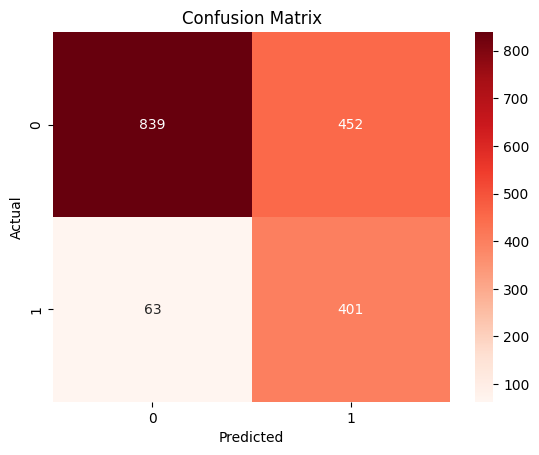

In [64]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

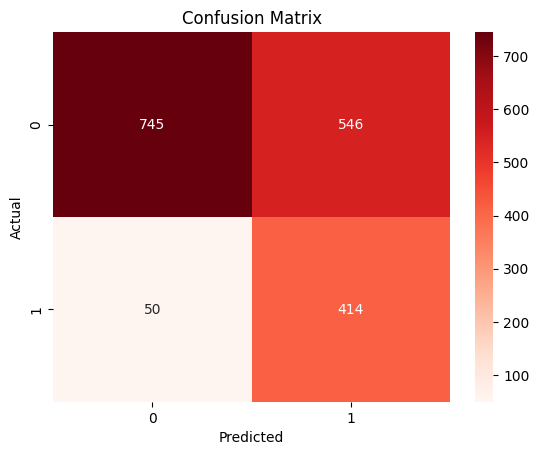

In [65]:
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Based on the evaluation results, Logistic Regression was selected as the final model.
It achieved 86% Recall, 47% Precision, and 61% F1-score for the Churn class.
Recall was prioritized because missing an actual churner (false negative) may be costly.

Threshold analysis

In [66]:
final_model = logistic_grid.best_estimator_

y_prob = final_model.predict_proba(X_test)[:, 1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.371
Recall:    0.953
F1 Score:  0.534
------------------------------
Threshold: 0.4
Precision: 0.411
Recall:    0.927
F1 Score:  0.570
------------------------------
Threshold: 0.5
Precision: 0.470
Recall:    0.864
F1 Score:  0.609
------------------------------
Threshold: 0.6
Precision: 0.569
Recall:    0.718
F1 Score:  0.635
------------------------------
Threshold: 0.7
Precision: 0.677
Recall:    0.532
F1 Score:  0.596
------------------------------


Threshold 0.5 gave better results for our analysis

In [67]:
from sklearn.metrics import roc_auc_score

y_prob = final_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.842


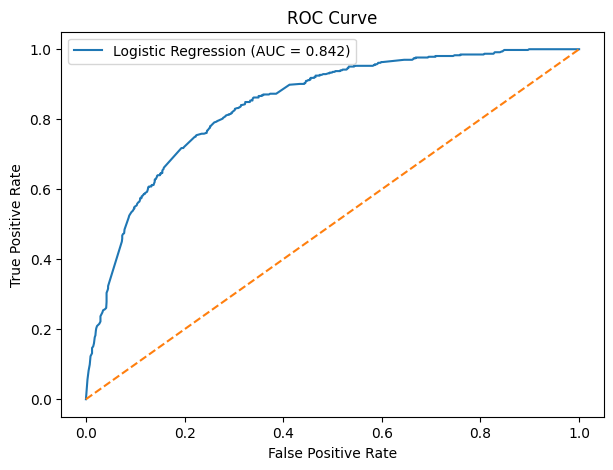

In [68]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [69]:
import joblib

final_model = logistic_grid.best_estimator_

joblib.dump(final_model, "telco_churn_model.pkl")

['telco_churn_model.pkl']